<a href="https://colab.research.google.com/github/KrishnaChaitanya-aiml/urban-traffic-congestion-analysis/blob/main/urban_traffic_congestion_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Urban Traffic Congestion Prediction with Adaptive Thresholding

## Problem Statement
Traffic congestion is a major issue in urban areas. Predicting congestion levels can help optimize traffic flow and improve smart city infrastructure.

## Objective
To analyze traffic data and classify congestion levels using adaptive thresholds based on statistical patterns.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data Simulation

Simulating vehicle count data to represent traffic flow over time.

In [2]:
# Generate synthetic traffic data
np.random.seed(42)

time = np.arange(0, 150)

# Normal traffic pattern
traffic = np.random.normal(loc=50, scale=10, size=150)

# Add congestion spikes
traffic[30:40] += 40
traffic[90:100] += 50

df = pd.DataFrame({
    'Time': time,
    'Vehicle_Count': traffic
})

df.head()

,Time,Vehicle_Count
0,0,54.967142
1,1,48.617357
2,2,56.476885
3,3,65.230299
4,4,47.658466


## Data Visualization

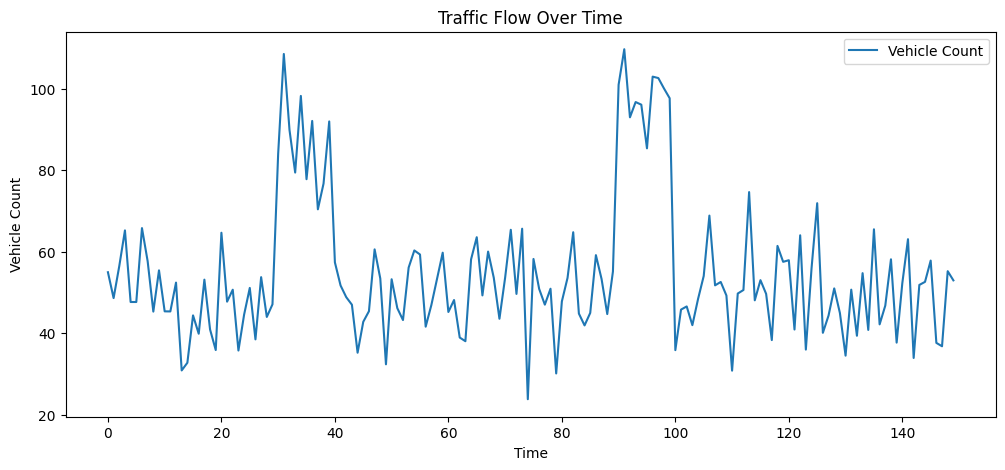

In [3]:
plt.figure(figsize=(12,5))
plt.plot(df['Time'], df['Vehicle_Count'], label='Vehicle Count')
plt.title("Traffic Flow Over Time")
plt.xlabel("Time")
plt.ylabel("Vehicle Count")
plt.legend()
plt.show()

## Adaptive Threshold Calculation

Instead of fixed thresholds, we dynamically calculate congestion levels based on mean and standard deviation.

In [4]:
# Calculate statistics
mean = df['Vehicle_Count'].mean()
std = df['Vehicle_Count'].std()

# Define thresholds
low_threshold = mean
high_threshold = mean + std

print("Mean:", mean)
print("High Threshold:", high_threshold)

Mean: 55.17673132847463
High Threshold: 72.8121990302487


## Congestion Classification

In [5]:
def classify_traffic(x):
    if x < low_threshold:
        return "Low"
    elif x < high_threshold:
        return "Medium"
    else:
        return "High"

df['Congestion_Level'] = df['Vehicle_Count'].apply(classify_traffic)

df.head()

,Time,Vehicle_Count,Congestion_Level
0,0,54.967142,Low
1,1,48.617357,Low
2,2,56.476885,Medium
3,3,65.230299,Medium
4,4,47.658466,Low


## Visualization of Congestion Levels

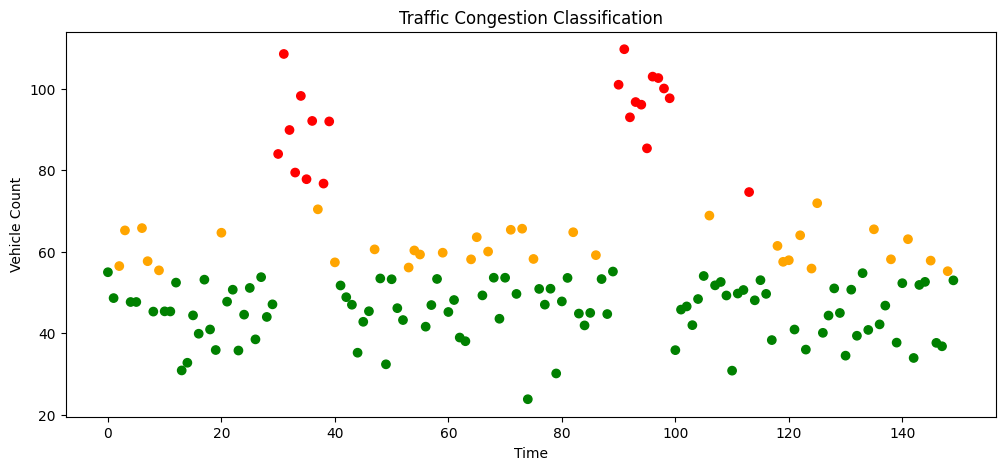

In [6]:
plt.figure(figsize=(12,5))

colors = df['Congestion_Level'].map({
    'Low': 'green',
    'Medium': 'orange',
    'High': 'red'
})

plt.scatter(df['Time'], df['Vehicle_Count'], c=colors)
plt.title("Traffic Congestion Classification")
plt.xlabel("Time")
plt.ylabel("Vehicle Count")
plt.show()

## Insights

- High congestion periods indicate peak traffic hours or abnormal spikes.
- Adaptive thresholding allows better classification compared to fixed limits.
- This approach can be extended to real-time smart traffic systems.

## Conclusion

The project demonstrates how traffic congestion can be analyzed and classified using simple statistical techniques. Such models can support intelligent traffic management systems in smart cities.